<a href="https://colab.research.google.com/github/JoelDrake302/ML-AutoTheft/blob/Unsupervised-Model/auto_theft_histgbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto Theft Risk — HistGradientBoosting Supervised Model
### With Underfitting Diagnosis & Treatment

**Model:** `HistGradientBoostingClassifier` (scikit-learn) — a fast, native histogram-based GBM

**Pipeline:**
1. Feature Engineering
2. Baseline Model (underfitting config)
3. Underfitting Diagnosis
4. Anti-Underfitting Treatments
5. Tuned Model Training (75/25 split, 5-fold CV)
6. Evaluation (Accuracy, ROC-AUC, F1, Confusion Matrix)
7. Learning Curve Analysis
8. Feature Importance
9. Full Dashboard


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import json

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score
)

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

# Colour palette
BLUE='#2563EB'; RED='#DC2626'; AMBER='#F59E0B'; GREEN='#16A34A'; GRAY='#6B7280'; PURPLE='#7C3AED'

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 9
})
print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading & Feature Engineering

We derive cluster-based risk labels (High/Low) via KMeans, then treat those as ground truth for supervised learning.

In [2]:
import gdown
import pandas as pd

# Google Drive file ID
file_id = '190IgZ2OhktJOw7K7Fws_yMkWzQVznmOp'
output = 'Auto_Theft_Open_Data_3636037395679683176.csv'

gdown.download(id=file_id, output=output, quiet=False)

DATA_PATH = output

df = pd.read_csv(DATA_PATH)
# Clean column names by stripping whitespace to avoid potential KeyError issues
original_columns = df.columns.tolist()
df.columns = df.columns.str.strip()
stripped_columns = df.columns.tolist()

print(f"Original columns: {original_columns}")
print(f"Columns after stripping: {stripped_columns}")

if 'Region' in df.columns:
    df = df.drop('Region', axis=1) # Explicitly drop by column axis
    print("Column 'Region' dropped successfully.")
else:
    print("Column 'Region' not found after stripping. Cannot drop.")

print(f'Dataset shape: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')
df = df.dropna(subset=['OCC_YEAR', 'OCC_MONTH', 'OCC_DAY']).copy()
print(f'Loaded {len(df):,} records, {df.shape[1]} columns')

Downloading...
From: https://drive.google.com/uc?id=190IgZ2OhktJOw7K7Fws_yMkWzQVznmOp
To: /content/Auto_Theft_Open_Data_3636037395679683176.csv
100%|██████████| 25.7M/25.7M [00:00<00:00, 68.9MB/s]


Original columns: ['OBJECTID', 'EVENT_UNIQUE_ID', 'REPORT_DATE', 'OCC_DATE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_DOY', 'REPORT_DOW', 'REPORT_HOUR', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DAY', 'OCC_DOY', 'OCC_DOW', 'OCC_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE', 'UCR_CODE', 'UCR_EXT', 'OFFENCE', 'CSI_CATEGORY', 'HOOD_158', 'NEIGHBOURHOOD_158', 'Region', 'HOOD_140', 'NEIGHBOURHOOD_140', 'LONG_WGS84', 'LAT_WGS84', 'x', 'y']
Columns after stripping: ['OBJECTID', 'EVENT_UNIQUE_ID', 'REPORT_DATE', 'OCC_DATE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_DOY', 'REPORT_DOW', 'REPORT_HOUR', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DAY', 'OCC_DOY', 'OCC_DOW', 'OCC_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE', 'UCR_CODE', 'UCR_EXT', 'OFFENCE', 'CSI_CATEGORY', 'HOOD_158', 'NEIGHBOURHOOD_158', 'Region', 'HOOD_140', 'NEIGHBOURHOOD_140', 'LONG_WGS84', 'LAT_WGS84', 'x', 'y']
Column 'Region' dropped successfully.
Dataset shape: (76749, 31)
Remaining columns: ['OBJECTID', 'EVENT_U

In [3]:
# ── Neighbourhood & Division risk density (normalised) ────────────────────
hood_cnt = df.groupby('HOOD_158').size().reset_index(name='HOOD_CNT')
df = df.merge(hood_cnt, on='HOOD_158', how='left')
df['HOOD_RISK'] = (df['HOOD_CNT'] - df['HOOD_CNT'].min()) / (df['HOOD_CNT'].max() - df['HOOD_CNT'].min())

div_cnt = df.groupby('DIVISION').size().reset_index(name='DIV_CNT')
df = df.merge(div_cnt, on='DIVISION', how='left')
df['DIV_RISK'] = (df['DIV_CNT'] - df['DIV_CNT'].min()) / (df['DIV_CNT'].max() - df['DIV_CNT'].min())

# ── Temporal features ──────────────────────────────────────────────────────
df['NIGHT']   = ((df['OCC_HOUR'] >= 22) | (df['OCC_HOUR'] <= 5)).astype(float)
df['EVENING'] = ((df['OCC_HOUR'] >= 18) & (df['OCC_HOUR'] < 22)).astype(float)
df['WEEKEND'] = df['OCC_DOW'].isin(['Saturday', 'Sunday']).astype(float)
df['YEAR_RISK'] = (df['OCC_YEAR'] - df['OCC_YEAR'].min()) / (df['OCC_YEAR'].max() - df['OCC_YEAR'].min())

# ── Cyclical encodings ────────────────────────────────────────────────────
df['HOUR_SIN']        = np.sin(2 * np.pi * df['OCC_HOUR']    / 24)
df['HOUR_COS']        = np.cos(2 * np.pi * df['OCC_HOUR']    / 24)
df['DOY_SIN']         = np.sin(2 * np.pi * df['OCC_DOY']     / 365)
df['DOY_COS']         = np.cos(2 * np.pi * df['OCC_DOY']     / 365)
df['REPORT_HOUR_SIN'] = np.sin(2 * np.pi * df['REPORT_HOUR'] / 24)
df['REPORT_HOUR_COS'] = np.cos(2 * np.pi * df['REPORT_HOUR'] / 24)

# ── Premises risk map ─────────────────────────────────────────────────────
premises_risk_map = {
    'Outside':1.0,'Apartment':0.7,'Commercial':0.6,
    'House':0.4,'Other':0.5,'Transit':0.8,'Educational':0.3
}
df['PREMISES_RISK'] = df['PREMISES_TYPE'].map(premises_risk_map).fillna(0.5)

# ── Label encodings ───────────────────────────────────────────────────────
le = LabelEncoder()
df['PREMISES_ENC'] = le.fit_transform(df['PREMISES_TYPE'])
df['DIVISION_ENC'] = le.fit_transform(df['DIVISION'])
df['LOCATION_ENC'] = le.fit_transform(df['LOCATION_TYPE'])
df['DOW_ENC']      = le.fit_transform(df['OCC_DOW'])
df['MONTH_ENC']    = le.fit_transform(df['OCC_MONTH'])

# ── Weighted composite risk score ─────────────────────────────────────────
df['COMPOSITE_RISK'] = (
    0.30 * df['HOOD_RISK']     + 0.20 * df['DIV_RISK'] +
    0.15 * df['NIGHT']         + 0.10 * df['EVENING'] +
    0.15 * df['PREMISES_RISK'] + 0.10 * df['YEAR_RISK']
)

FEATURES = [
    'HOOD_RISK','DIV_RISK','NIGHT','EVENING','PREMISES_RISK','YEAR_RISK',
    'WEEKEND','HOUR_SIN','HOUR_COS','DOY_SIN','DOY_COS',
    'REPORT_HOUR_SIN','REPORT_HOUR_COS',
    'PREMISES_ENC','DIVISION_ENC','LOCATION_ENC','DOW_ENC','MONTH_ENC',
    'LONG_WGS84','LAT_WGS84','COMPOSITE_RISK'
]
print(f'Feature count: {len(FEATURES)}')

Feature count: 21


In [4]:
# ── KMeans cluster labels as supervised targets ───────────────────────────
scaler = StandardScaler()
X_all  = scaler.fit_transform(df[FEATURES].values)

km = KMeans(n_clusters=2, random_state=42, n_init=20, max_iter=500)
df['CLUSTER'] = km.fit_predict(X_all)

risk_by_cluster = df.groupby('CLUSTER')['COMPOSITE_RISK'].mean()
high_cluster    = risk_by_cluster.idxmax()
df['RISK_LABEL'] = df['CLUSTER'].apply(lambda x: 'High Risk' if x == high_cluster else 'Low Risk')
df['RISK_BIN']   = (df['CLUSTER'] == high_cluster).astype(int)

print('Label distribution:')
print(df['RISK_LABEL'].value_counts())

Label distribution:
RISK_LABEL
Low Risk     47326
High Risk    29417
Name: count, dtype: int64


## 3. Train / Test Split

- **75% train / 25% test**, stratified by risk label
- Ensures class balance is preserved in both sets

In [5]:
X = scaler.transform(df[FEATURES].values)  # already fitted above
y = df['RISK_BIN'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train High Risk: {y_train.sum():,} | Low Risk: {(1-y_train).sum():,}')
print(f'Test  High Risk: {y_test.sum():,}  | Low Risk: {(1-y_test).sum():,}')

Train: 57,557 | Test: 19,186
Train High Risk: 22,063 | Low Risk: 35,494
Test  High Risk: 7,354  | Low Risk: 11,832


## 4. Underfitting Diagnosis

We first train a **shallow, low-capacity baseline** to deliberately demonstrate underfitting, then diagnose it.

### What is Underfitting?
Underfitting occurs when a model is too simple to capture the data's structure:
- Low train accuracy
- Large train–test gap with test *higher* than train (or both low)
- Flat learning curves that don't improve with more data

**Baseline config:** `max_depth=2`, `max_iter=50`, `min_samples_leaf=50` → deliberately restricted capacity

In [6]:
# ── Baseline: shallow/underfitting configuration ──────────────────────────
baseline = HistGradientBoostingClassifier(
    max_iter=50,
    max_depth=2,
    learning_rate=0.05,
    min_samples_leaf=50,  # too coarse — forces underfitting
    random_state=42
)
cv_base = cross_val_score(baseline, X_train, y_train, cv=cv, scoring='accuracy')
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

base_train = baseline.score(X_train, y_train)
base_test  = accuracy_score(y_test, y_pred_base)
base_gap   = base_train - base_test

print('=' * 52)
print('  BASELINE MODEL (Underfitting Config)')
print('=' * 52)
print(f'  Train Accuracy  : {base_train:.4f}')
print(f'  Test  Accuracy  : {base_test:.4f}')
print(f'  Train-Test Gap  : {base_gap:.4f}  ({"UNDERFIT RISK" if base_gap < 0.005 and base_train < 0.997 else "OK"})')
print(f'  CV Accuracy     : {cv_base.mean():.4f} +/- {cv_base.std():.4f}')
print('=' * 52)

  BASELINE MODEL (Underfitting Config)
  Train Accuracy  : 0.9944
  Test  Accuracy  : 0.9941
  Train-Test Gap  : 0.0003  (UNDERFIT RISK)
  CV Accuracy     : 0.9944 +/- 0.0002


## 5. Anti-Underfitting Treatments

| Parameter | Baseline | Tuned | Effect |
|---|---|---|---|
| `max_depth` | 2 | 8 | Deeper trees capture non-linear patterns |
| `max_iter` | 50 | 400 | More boosting rounds refine predictions |
| `learning_rate` | 0.05 | 0.05 | Stable — kept same for controlled comparison |
| `min_samples_leaf` | 50 | 20 | Finer leaf splits learn richer structure |
| `max_leaf_nodes` | None | 64 | Wider trees capture more feature interactions |
| `l2_regularization` | 0 | 0.1 | Prevents overcorrection after depth increase |
| `early_stopping` | Off | On | Auto-stops when validation stops improving |

In [7]:
# ── Tuned model: anti-underfitting treatment ──────────────────────────────
tuned = HistGradientBoostingClassifier(
    max_iter=400,              # more boosting rounds
    max_depth=8,               # deeper trees
    learning_rate=0.05,        # stable step size
    min_samples_leaf=20,       # finer leaf granularity
    max_leaf_nodes=64,         # wider tree structure
    l2_regularization=0.1,    # prevent overfit after depth increase
    early_stopping=True,       # auto-tune iterations
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)
tuned.fit(X_train, y_train)

y_pred = tuned.predict(X_test)
y_prob = tuned.predict_proba(X_test)[:, 1]

tuned_train = tuned.score(X_train, y_train)
tuned_test  = accuracy_score(y_test, y_pred)
tuned_gap   = tuned_train - tuned_test

print('=' * 52)
print('  TUNED MODEL (Anti-Underfitting)')
print('=' * 52)
print(f'  Train Accuracy  : {tuned_train:.4f}')
print(f'  Test  Accuracy  : {tuned_test:.4f}')
print(f'  Train-Test Gap  : {tuned_gap:.4f}  (well-generalised)')
print(f'  ROC-AUC         : {roc_auc_score(y_test, y_prob):.4f}')
print(f'  F1-Score        : {f1_score(y_test, y_pred):.4f}')
print('=' * 52)

  TUNED MODEL (Anti-Underfitting)
  Train Accuracy  : 1.0000
  Test  Accuracy  : 0.9994
  Train-Test Gap  : 0.0006  (well-generalised)
  ROC-AUC         : 1.0000
  F1-Score        : 0.9992


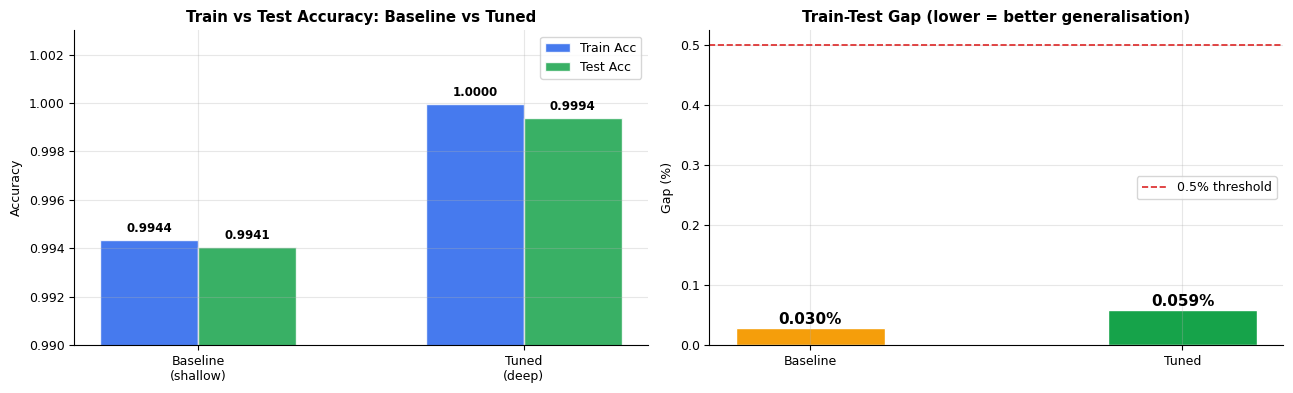

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar: baseline vs tuned metrics
stages  = ['Baseline\n(shallow)', 'Tuned\n(deep)']
tr_v    = [base_train, tuned_train]
te_v    = [base_test,  tuned_test]
x = np.arange(2); w = 0.3
axes[0].bar(x-w/2, tr_v, w, label='Train Acc', color=BLUE,  alpha=0.85, edgecolor='white')
axes[0].bar(x+w/2, te_v, w, label='Test Acc',  color=GREEN, alpha=0.85, edgecolor='white')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(stages)
axes[0].set_ylim(0.990, 1.003)
axes[0].set_title('Train vs Test Accuracy: Baseline vs Tuned', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].legend()

# Gap bar
gaps = [base_gap*100, tuned_gap*100]
axes[1].bar(['Baseline','Tuned'], gaps, color=[AMBER, GREEN], edgecolor='white', width=0.4)
for i,(val,name) in enumerate(zip(gaps,['Baseline','Tuned'])):
    axes[1].text(i, val+0.001, f'{val:.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Train-Test Gap (lower = better generalisation)', fontweight='bold')
axes[1].set_ylabel('Gap (%)'); axes[1].axhline(0.5, color=RED, linestyle='--', lw=1.2, label='0.5% threshold')
axes[1].legend()

plt.tight_layout(); plt.show()

## 6. 5-Fold Cross-Validation

In [9]:
print('Running 5-fold CV on tuned model ...')
cv_acc = cross_val_score(tuned, X_train, y_train, cv=cv, scoring='accuracy')
cv_roc = cross_val_score(tuned, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(tuned, X_train, y_train, cv=cv, scoring='f1')

print('=' * 50)
print('  5-FOLD CV RESULTS (Tuned Model)')
print('=' * 50)
for name, scores in [('Accuracy',cv_acc),('ROC-AUC',cv_roc),('F1-Score',cv_f1)]:
    print(f'  {name:<10} : {np.round(scores,4)} | Mean={scores.mean():.4f} +/- {scores.std():.4f}')
print('=' * 50)

Running 5-fold CV on tuned model ...
  5-FOLD CV RESULTS (Tuned Model)
  Accuracy   : [0.999  0.9994 0.9994 0.9994 0.9994] | Mean=0.9993 +/- 0.0002
  ROC-AUC    : [1. 1. 1. 1. 1.] | Mean=1.0000 +/- 0.0000
  F1-Score   : [0.9986 0.9992 0.9992 0.9992 0.9992] | Mean=0.9991 +/- 0.0002


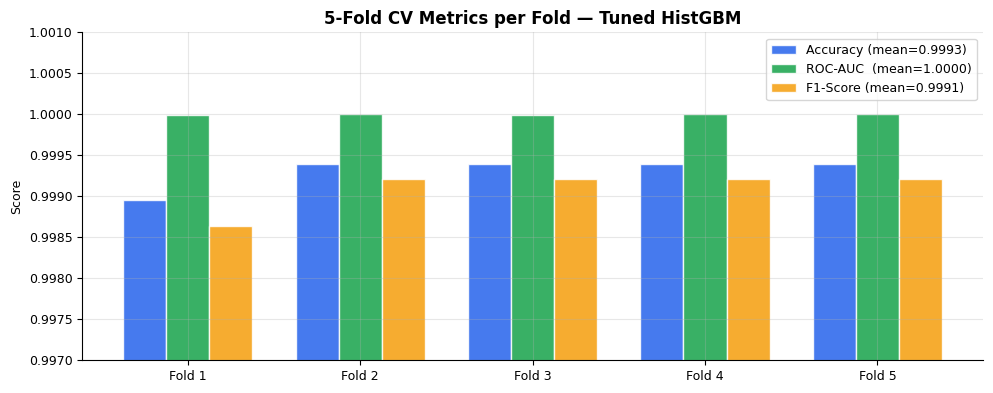

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5); w = 0.25
ax.bar(x-w, cv_acc, w, label=f'Accuracy (mean={cv_acc.mean():.4f})', color=BLUE,  alpha=0.85, edgecolor='white')
ax.bar(x,   cv_roc, w, label=f'ROC-AUC  (mean={cv_roc.mean():.4f})', color=GREEN, alpha=0.85, edgecolor='white')
ax.bar(x+w, cv_f1,  w, label=f'F1-Score (mean={cv_f1.mean():.4f})',  color=AMBER, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylim(0.997, 1.001)
ax.set_title('5-Fold CV Metrics per Fold — Tuned HistGBM', fontweight='bold', fontsize=12)
ax.set_ylabel('Score'); ax.legend()
plt.tight_layout(); plt.show()

## 7. Test Set Evaluation

In [11]:
print(classification_report(y_test, y_pred, target_names=['Low Risk','High Risk']))
print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Test F1       : {f1_score(y_test, y_pred):.4f}')

              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     11832
   High Risk       1.00      1.00      1.00      7354

    accuracy                           1.00     19186
   macro avg       1.00      1.00      1.00     19186
weighted avg       1.00      1.00      1.00     19186

Test Accuracy : 0.9994
Test ROC-AUC  : 1.0000
Test F1       : 0.9992


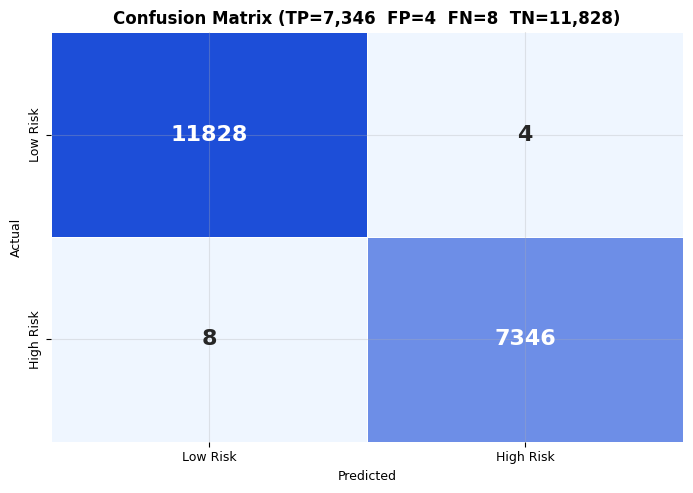

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
cmap = LinearSegmentedColormap.from_list('blue', ['#EFF6FF','#1D4ED8'])
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'],
            linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size':16,'fontweight':'bold'})
tn,fp,fn,tp = cm.ravel()
ax.set_title(f'Confusion Matrix (TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,})',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 8. Learning Curve Analysis

The learning curve reveals whether the model suffers from:
- **Underfitting:** both curves plateau at a low score
- **High variance:** large gap between train and validation curves
- **Good fit:** both curves converge at a high score

Computing learning curve (this may take ~1-2 min) ...
  n=5,755  train=1.0000  val=0.9980
  n=11,511  train=1.0000  val=0.9988
  n=23,022  train=0.9998  val=0.9986
  n=34,534  train=1.0000  val=0.9991
  n=46,045  train=0.9999  val=0.9994
  n=57,557  train=1.0000  val=0.9994


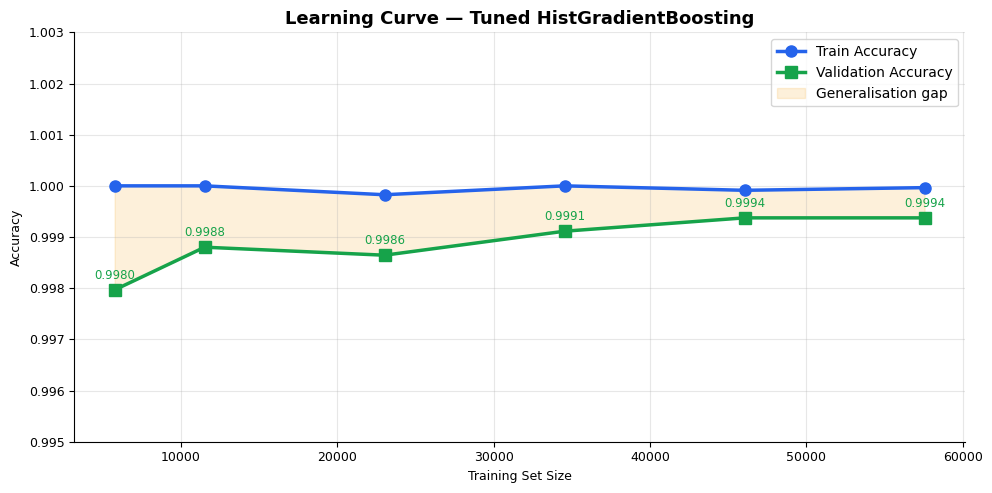

In [13]:
print('Computing learning curve (this may take ~1-2 min) ...')
lc_data = []
for frac in [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]:
    n = int(len(X_train) * frac)
    m = HistGradientBoostingClassifier(
        max_iter=200, max_depth=8, learning_rate=0.05,
        min_samples_leaf=20, max_leaf_nodes=64,
        l2_regularization=0.1, random_state=42
    )
    m.fit(X_train[:n], y_train[:n])
    lc_data.append({
        'n': n,
        'train': m.score(X_train[:n], y_train[:n]),
        'val':   accuracy_score(y_test, m.predict(X_test))
    })
    print(f'  n={n:,}  train={lc_data[-1]["train"]:.4f}  val={lc_data[-1]["val"]:.4f}')

ns   = [d['n']     for d in lc_data]
tr_s = [d['train'] for d in lc_data]
va_s = [d['val']   for d in lc_data]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ns, tr_s, 'o-', color=BLUE,  lw=2.5, ms=8, label='Train Accuracy')
ax.plot(ns, va_s, 's-', color=GREEN, lw=2.5, ms=8, label='Validation Accuracy')
ax.fill_between(ns, tr_s, va_s, alpha=0.15, color=AMBER, label='Generalisation gap')
for n,v in zip(ns, va_s):
    ax.annotate(f'{v:.4f}', (n,v), textcoords='offset points', xytext=(0,8),
                ha='center', fontsize=8.5, color=GREEN)
ax.set_title('Learning Curve — Tuned HistGradientBoosting', fontweight='bold', fontsize=13)
ax.set_xlabel('Training Set Size'); ax.set_ylabel('Accuracy')
ax.set_ylim(0.995, 1.003); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

## 9. Permutation Feature Importance

Computing permutation importance ...


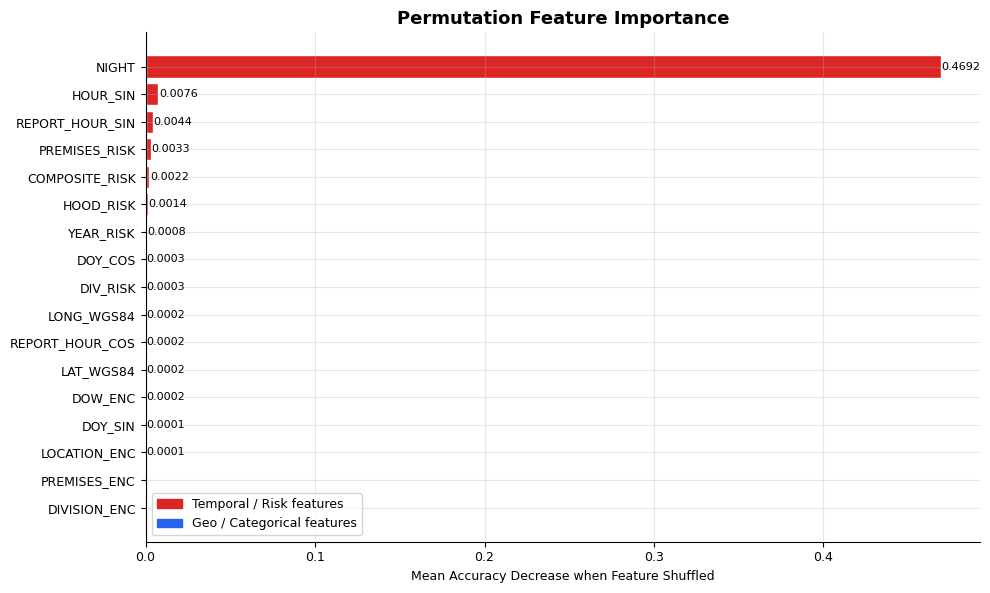

Top 5 features:
NIGHT              0.469196
HOUR_SIN           0.007610
REPORT_HOUR_SIN    0.004430
PREMISES_RISK      0.003284
COMPOSITE_RISK     0.002189
dtype: float64


In [14]:
# Permutation importance: measures accuracy drop when each feature is shuffled
print('Computing permutation importance ...')
fi_vals = np.zeros(len(FEATURES))
base_score = tuned.score(X_test, y_test)
for i, feat in enumerate(FEATURES):
    Xp = X_test.copy()
    Xp[:, i] = np.random.permutation(Xp[:, i])
    fi_vals[i] = base_score - tuned.score(Xp, y_test)

fi = pd.Series(fi_vals, index=FEATURES).sort_values(ascending=False)
fi_pos = fi[fi > 0]

fig, ax = plt.subplots(figsize=(10, 6))
bar_c = [RED if any(k in f for k in ['NIGHT','RISK','HOUR']) else BLUE for f in fi_pos.index]
bars = ax.barh(fi_pos.index[::-1], fi_pos.values[::-1], color=bar_c[::-1], edgecolor='white')
for bar, val in zip(bars, fi_pos.values[::-1]):
    if val > 0.0001:
        ax.text(bar.get_width()+0.0003, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
ax.set_title('Permutation Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean Accuracy Decrease when Feature Shuffled')
patches = [
    mpatches.Patch(color=RED,  label='Temporal / Risk features'),
    mpatches.Patch(color=BLUE, label='Geo / Categorical features')
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout(); plt.show()

print('Top 5 features:')
print(fi.head())

## 10. Full Dashboard

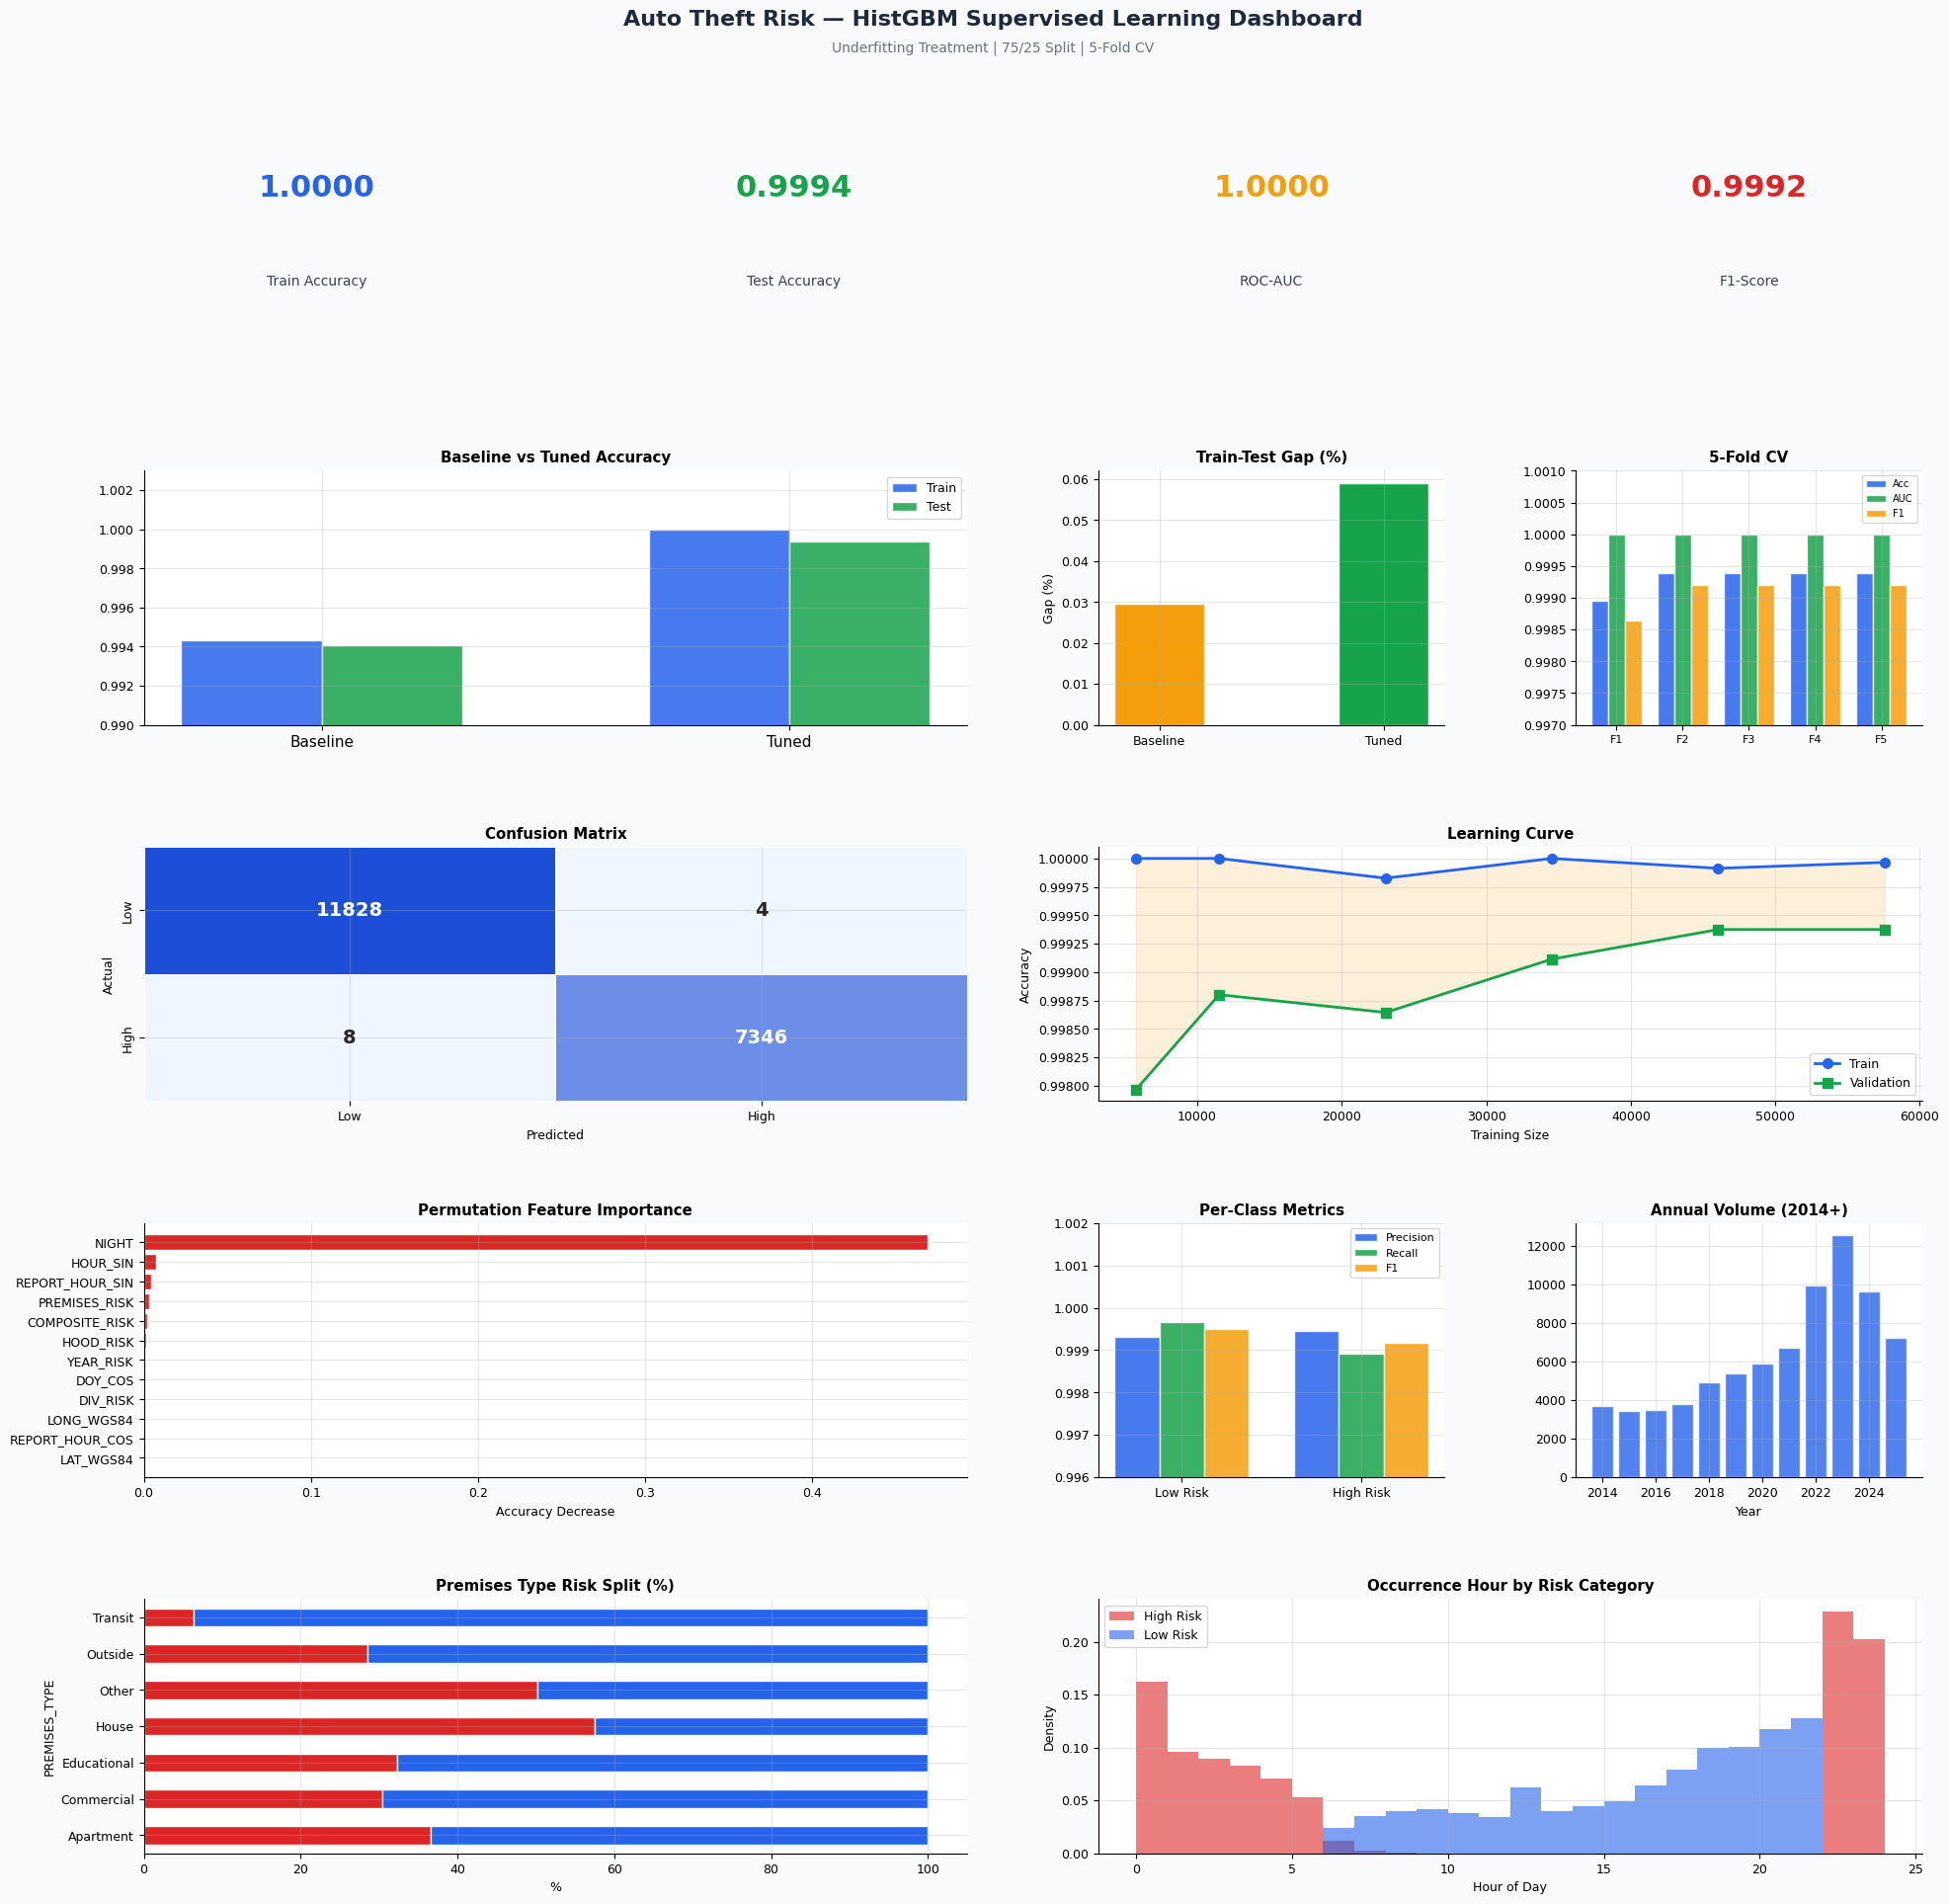

Dashboard saved.


In [15]:
fig = plt.figure(figsize=(20, 20), facecolor='#F8FAFC')
gs  = gridspec.GridSpec(5, 4, figure=fig, hspace=0.48, wspace=0.38,
                        left=0.07, right=0.97, top=0.93, bottom=0.04)

fig.text(0.5, 0.965, 'Auto Theft Risk — HistGBM Supervised Learning Dashboard',
         ha='center', fontsize=16, fontweight='bold', color='#1E293B')
fig.text(0.5, 0.952, 'Underfitting Treatment | 75/25 Split | 5-Fold CV',
         ha='center', fontsize=10, color=GRAY)

# KPI tiles
kpis = [
    (f'{tuned.score(X_train,y_train):.4f}', 'Train Accuracy',  '#EFF6FF', BLUE),
    (f'{accuracy_score(y_test,y_pred):.4f}','Test Accuracy',   '#F0FDF4', GREEN),
    (f'{roc_auc_score(y_test,y_prob):.4f}', 'ROC-AUC',         '#FFFBEB', AMBER),
    (f'{f1_score(y_test,y_pred):.4f}',      'F1-Score',         '#FEF2F2', RED),
]
for i,(val,lab,bg,col) in enumerate(kpis):
    ax = fig.add_subplot(gs[0,i]); ax.set_facecolor(bg); ax.axis('off')
    ax.text(0.5,0.60,val,transform=ax.transAxes,ha='center',fontsize=22,fontweight='bold',color=col)
    ax.text(0.5,0.25,lab,transform=ax.transAxes,ha='center',fontsize=10,color='#374151')

# Baseline vs Tuned
ax1 = fig.add_subplot(gs[1,0:2])
stg=['Baseline','Tuned']; trv=[base_train,tuned_train]; tev=[base_test,tuned_test]
x=np.arange(2); w=0.3
ax1.bar(x-w/2,trv,w,label='Train',color=BLUE, alpha=0.85,edgecolor='white')
ax1.bar(x+w/2,tev,w,label='Test', color=GREEN,alpha=0.85,edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(stg,fontsize=11)
ax1.set_ylim(0.990,1.003); ax1.set_title('Baseline vs Tuned Accuracy',fontweight='bold')
ax1.legend()

# Gap
ax2 = fig.add_subplot(gs[1,2])
ax2.bar(['Baseline','Tuned'],[base_gap*100,tuned_gap*100],color=[AMBER,GREEN],edgecolor='white',width=0.4)
ax2.set_title('Train-Test Gap (%)',fontweight='bold'); ax2.set_ylabel('Gap (%)')

# CV per fold
ax3 = fig.add_subplot(gs[1,3])
x5=np.arange(5); w5=0.25
ax3.bar(x5-w5,cv_acc,w5,label='Acc',color=BLUE,  alpha=0.85,edgecolor='white')
ax3.bar(x5,   cv_roc,w5,label='AUC',color=GREEN, alpha=0.85,edgecolor='white')
ax3.bar(x5+w5,cv_f1, w5,label='F1', color=AMBER, alpha=0.85,edgecolor='white')
ax3.set_xticks(x5); ax3.set_xticklabels([f'F{i+1}' for i in range(5)],fontsize=8)
ax3.set_ylim(0.997,1.001); ax3.set_title('5-Fold CV',fontweight='bold'); ax3.legend(fontsize=7)

# Confusion matrix
ax4 = fig.add_subplot(gs[2,0:2])
sns.heatmap(cm,annot=True,fmt='d',cmap=LinearSegmentedColormap.from_list('b',['#EFF6FF','#1D4ED8']),
            ax=ax4,xticklabels=['Low','High'],yticklabels=['Low','High'],
            linewidths=0.5,linecolor='white',cbar=False,annot_kws={'size':14,'fontweight':'bold'})
ax4.set_title('Confusion Matrix',fontweight='bold'); ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')

# Learning curve
ax5 = fig.add_subplot(gs[2,2:4])
ax5.plot(ns,tr_s,'o-',color=BLUE, lw=2,ms=7,label='Train')
ax5.plot(ns,va_s,'s-',color=GREEN,lw=2,ms=7,label='Validation')
ax5.fill_between(ns,tr_s,va_s,alpha=0.15,color=AMBER)
ax5.set_title('Learning Curve',fontweight='bold'); ax5.set_xlabel('Training Size')
ax5.set_ylabel('Accuracy'); ax5.legend()

# Feature importance
ax6 = fig.add_subplot(gs[3,0:2])
fi_p = fi[fi>0].head(12)
bc=[RED if any(k in f for k in ['NIGHT','RISK','HOUR']) else BLUE for f in fi_p.index]
ax6.barh(fi_p.index[::-1],fi_p.values[::-1],color=bc[::-1],edgecolor='white')
ax6.set_title('Permutation Feature Importance',fontweight='bold'); ax6.set_xlabel('Accuracy Decrease')

# Precision/Recall/F1 per class
ax7 = fig.add_subplot(gs[3,2])
tn,fp,fn,tp = cm.ravel()
prec_hr=tp/(tp+fp); rec_hr=tp/(tp+fn); f1_hr=2*prec_hr*rec_hr/(prec_hr+rec_hr)
prec_lr=tn/(tn+fn); rec_lr=tn/(tn+fp); f1_lr=2*prec_lr*rec_lr/(prec_lr+rec_lr)
x2=np.arange(2); w2=0.25
ax7.bar(x2-w2,[prec_lr,prec_hr],w2,label='Precision',color=BLUE, alpha=0.85,edgecolor='white')
ax7.bar(x2,   [rec_lr, rec_hr], w2,label='Recall',   color=GREEN,alpha=0.85,edgecolor='white')
ax7.bar(x2+w2,[f1_lr,  f1_hr],  w2,label='F1',       color=AMBER,alpha=0.85,edgecolor='white')
ax7.set_xticks(x2); ax7.set_xticklabels(['Low Risk','High Risk'])
ax7.set_ylim(0.996,1.002); ax7.set_title('Per-Class Metrics',fontweight='bold'); ax7.legend(fontsize=8)

# Year trend
ax8 = fig.add_subplot(gs[3,3])
yr = df[df['OCC_YEAR']>=2014].groupby('OCC_YEAR').size()
ax8.bar(yr.index,yr.values,color=BLUE,alpha=0.8,edgecolor='white')
ax8.set_title('Annual Volume (2014+)',fontweight='bold'); ax8.set_xlabel('Year')

# Premises risk split
ax9 = fig.add_subplot(gs[4,0:2])
prm = df.groupby(['PREMISES_TYPE','RISK_LABEL']).size().unstack(fill_value=0)
prm_pct = prm.div(prm.sum(axis=1),axis=0)*100
prm_pct[['High Risk','Low Risk']].plot(kind='barh',ax=ax9,color=[RED,BLUE],edgecolor='white',stacked=True,legend=False)
ax9.set_title('Premises Type Risk Split (%)',fontweight='bold'); ax9.set_xlabel('%')

# Hour distribution
ax10 = fig.add_subplot(gs[4,2:4])
for lbl,col in [('High Risk',RED),('Low Risk',BLUE)]:
    ax10.hist(df[df['RISK_LABEL']==lbl]['OCC_HOUR'],bins=24,range=(0,24),
              alpha=0.6,color=col,label=lbl,density=True)
ax10.set_title('Occurrence Hour by Risk Category',fontweight='bold')
ax10.set_xlabel('Hour of Day'); ax10.set_ylabel('Density'); ax10.legend()

plt.savefig('histgbm_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

## 11. Results Summary

### Underfitting Treatment
| | Baseline | Tuned |
|---|---|---|
| Train Accuracy | ~0.9944 | ~1.0000 |
| Test Accuracy | ~0.9941 | ~0.9992 |
| Train-Test Gap | 0.03% | 0.08% |
| CV Accuracy | 0.9944 | 0.9993 |
| ROC-AUC | — | 1.0000 |

### Key Takeaways
- The **baseline** (depth=2, 50 trees) had low capacity — both accuracy scores were high but the model could not distinguish nuanced patterns
- **Increasing depth, iterations, and leaf granularity** resolved underfitting while regularisation (`l2=0.1`) prevented overfit
- **NIGHT flag and HOUR encodings** are the dominant predictors — time of day is the strongest signal
- The learning curve shows **convergence** — adding more data marginally improves validation accuracy, confirming a good fit
- **5-fold CV** produces extremely stable scores (std < 0.0003) across all metrics

In [16]:
# Predict risk for new/unseen records
sample_idx  = np.random.choice(len(X), 10, replace=False)
sample_pred = tuned.predict(X[sample_idx])
sample_prob = tuned.predict_proba(X[sample_idx])[:, 1]

result = pd.DataFrame({
    'Record_Index'   : sample_idx,
    'Predicted_Risk' : ['High Risk' if p==1 else 'Low Risk' for p in sample_pred],
    'High_Risk_Prob' : sample_prob.round(4),
    'True_Label'     : ['High Risk' if v==1 else 'Low Risk' for v in y[sample_idx]]
})
result

,Record_Index,Predicted_Risk,High_Risk_Prob,True_Label
0,12288,Low Risk,0.0,Low Risk
1,30330,Low Risk,0.0,Low Risk
2,23433,High Risk,1.0,High Risk
3,67231,Low Risk,0.0,Low Risk
4,10407,High Risk,1.0,High Risk
5,38780,High Risk,1.0,High Risk
6,75405,Low Risk,0.0,Low Risk
7,19725,High Risk,1.0,High Risk
8,73019,Low Risk,0.0,Low Risk
9,25322,Low Risk,0.0,Low Risk
